### Project Overview

This notebook builds and trains the two neural networks to analyze waveform data from the Majorana Demonstrator, an experiment searching for neutrinoless double-beta decay.

**Part 1** sets a custom PyTorch 'dataset' class to load and normalize the raw waveform data.

**Part 2** builds a 1D CNN to classify each waveform as signal-like or background-like.

**Part 3** builds a separate regression network to predict the energy of each waveform event.

This was completed as the final project for PHYS41: Scientific Computing in Python at  UC San Diego. Dataset paths reference UCSD's internal Data Hub environment and won't run without that setup.

In [1]:
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data as data_utils
from torch.utils.data import Dataset, SubsetRandomSampler
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tqdm import tqdm


Here we define a few directories where our data is located at.

In [2]:
homedir = os.path.expanduser('~')
train_waveform = os.path.join(homedir, "public", "train_waveform_small.npy")
train_energy = os.path.join(homedir, "public", "train_energy.npy")
train_label = os.path.join(homedir, "public", "train_label.npy")
test_waveform = os.path.join(homedir, "public", "test_waveform_small.npy")
test_energy = os.path.join(homedir, "public", "test_energy.npy")
test_label = os.path.join(homedir, "public", "test_label.npy")


---

## Part 1: Data Structure

Before we start building the neural network, we must first establish the underlying data structure it will utilize and apply any necessary preprocessing. PyTorch provides a highly organized `Dataset` class for this exact purpose.

The custom dataset overrides three core methods:

* `__init__`: Contains the initialization logic for the dataset. This method is called once when the dataset object is instantiated.
* `__len__`: Returns the total size of the dataset. This method is called tp use the `len(dataset_object)` function.
* `__getitem__`: Takes an index argument (`idx`) and returns a single data sample (or event) corresponding to that index per call.



In [ ]:
class NeutrinoDataset(Dataset):

    def __init__(self,data_file, energy_file, label_file, hackathon=False):
        self.data = np.load(data_file)
        if hackathon:
            self.labels = np.zeros(len(self.data))
            self.energies = np.zeros(len(self.data))
        else:
            self.labels = np.load(label_file)
            self.energies = np.load(energy_file)

        print(f"Dataset Waveform Size:{self.data.shape}")
        print(f"Dataset Energy Label Size:{self.energies.shape}")
        print(f"Dataset Classification Label Size:{self.labels.shape}")

        self.size = len(self.data)


        data64 = self.data.astype(np.float64)
        mean = data64.mean()
        std = data64.std() + 1e-8
        self.data = ((data64 - mean) / std).astype(np.float32)
        self.labels = self.labels.astype(np.int64)
        self.energies = self.energies.astype(np.float32)



    def __len__(self):
        '''
        This function returns the size of overall dataset
        '''
        return self.size


    def __getitem__(self, idx):
        '''
        This function extract a single waveform from the dataset at the given index idx
        '''
        wf = torch.tensor(self.data[idx])
        label = torch.tensor(self.labels[idx])
        energy = torch.tensor(self.energies[idx])


        return wf, label, energy

The following cell contains two helper functions required for the neural network structure.

In [ ]:
def get_dataloader(dataset, bsize, shuffle=True):
    train_indices = list(range(len(dataset)))
    np.random.shuffle(train_indices)

    # Define two subset random sampler to sample events according to the training indices
    train_sampler = SubsetRandomSampler(train_indices)
    '''
    Finally, we define the loader by passing in the dataset, batch size and corresponding sampler
    Note that the number of data in each sub-dataset might not be divisibe by the batch size,
    so drop_last=True drops the last batch with all the residual events.
    '''
    if shuffle:
        train_loader = data_utils.DataLoader(dataset, batch_size=bsize, sampler=train_sampler, drop_last=True)
    else:
        train_loader = data_utils.DataLoader(dataset, batch_size=bsize, drop_last=False)
    return train_loader

def set_up_classifier(network, optim, loss):
    classifier = network() # Change here to try different networks
    classifier.to(DEVICE)

    print("# of params in model: ", sum(x.numel() for x in classifier.parameters()))

    criterion = loss()
    criterion = criterion.to(DEVICE)

    #Define the optimizer
    optimizer = optim(classifier.parameters(),lr=LEARNING_RATE)

    return classifier, criterion, optimizer

Now that we have defined our `NeutrinoDataset` class, let's instantiate it and extract a single event to verify its structure. The code below retrieves the first item from the training set and prints its shape, label, and energy.

Visualizing raw data is a crucial step in understanding the physical signals neural network will be learning from!

Dataset Waveform Size:(10000, 3800)
Dataset Energy Label Size:(10000,)
Dataset Classification Label Size:(10000,)
torch.Size([3800]) tensor(1) tensor(583.9676)


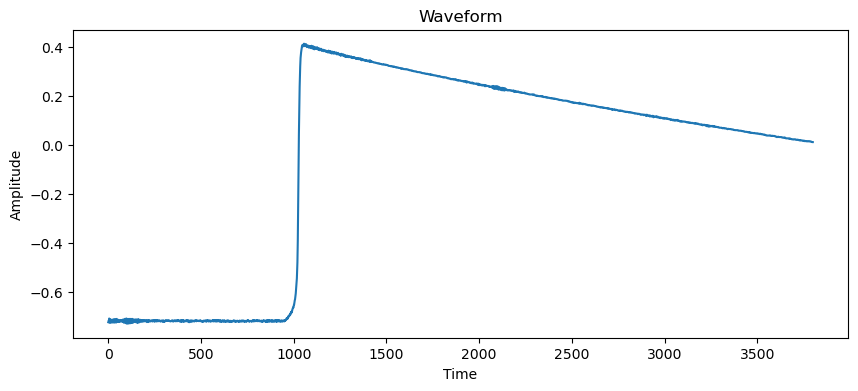

In [ ]:
train_set = NeutrinoDataset(train_waveform, train_energy, train_label)
one_event, one_label, one_energy = next(iter(train_set))
print(one_event.shape, one_label, one_energy)


plt.figure(figsize=(10, 4))
plt.plot(one_event)
plt.title("Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

---
## Part II: Label Classification

This section builds a neural network model for the binary classification task.

* The network must accept a waveform as input and output a **floating-point number** between 0 and 1, representing the classification score.
* A score closer to 1 indicates the waveform is more **signal-like**, while a score closer to 0 indicates it is more **background-like**.



We will follow a standard three-step machine learning workflow: **1.Network Design**, **2.Training**, and **3.Validation**.

### 1. Network Design
The design phase consists of two main steps:
1.  **Define the Architecture:** Create the `LabelNetwork` class as a PyTorch `nn.Module`. This is the core step to define the layers and the forward pass of network.
2.  **Validate the Structure:** A single event from `train_set` is passed through the untrained network to validate the architecture.

Let's begin with defining the architecture:

In [ ]:
class LabelNetwork(nn.Module):
    def __init__(self):
        super(LabelNetwork, self).__init__()


        self.conv1 = nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(16)


        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(128)

        self.fc1 = nn.Linear(128*16, 256)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, 1)


        self.dropout = nn.Dropout(0.5)



    def forward(self, x):

        # x = x.unsqueeze(1)
        x = x.contiguous().unsqueeze(1)

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool1d(x, kernel_size=2)

        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool1d(x, kernel_size=2)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        output = torch.sigmoid(self.fc3(x))
        # output = self.fc3(x).squeeze()

        return output

A single event is passed through the network to confirm the architecture and tensor shapes are correct.
  - Notice in the code that we insert a batch dimension and repeat the single event 8 times. We do this to simulate a batch size of 8, because passing a batch size of 1 will cause Batch Normalization layers to throw an error.
  
The printed shapes confirm the architecture handles a batch of 8 events correctly.

In [ ]:

one_event, one_label, one_energy = next(iter(train_set))
one_event = torch.FloatTensor(one_event).unsqueeze(0).expand(8,-1)
test_network = LabelNetwork()
print(test_network(one_event,))

tensor([[0.4705],
        [0.5349],
        [0.4184],
        [0.4822],
        [0.4603],
        [0.5014],
        [0.4444],
        [0.5068]], grad_fn=<SigmoidBackward0>)


### 2. Training
With the neural network architecture complete, BCELoss was used as the loss function for this classification task.

Loss values for this tas typically fall between **0.4 and 0.8**.

* **Stabilization with Batch Normalization:** If loss values are significantly higher than this range, network may be struggling to converge, adding at least one `nn.BatchNorm1d` layer to model architecture might be beneficial.

In [ ]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # This says if GPU is available, use GPU, otherwise use CPU



NUM_EPOCHS =50
LEARNING_RATE =2e-4 # 1e-3 is a good learning rate for general purpose
BATCH_SIZE=32
NETWORK = LabelNetwork
TRAIN_SET =  NeutrinoDataset(train_waveform, train_energy, train_label)
TEST_SET =  NeutrinoDataset(test_waveform, test_energy, test_label)
OPTIMIZER = torch.optim.Adam
LOSS_FUNCTION = torch.nn.BCELoss

Dataset Waveform Size:(10000, 3800)
Dataset Energy Label Size:(10000,)
Dataset Classification Label Size:(10000,)
Dataset Waveform Size:(10000, 3800)
Dataset Energy Label Size:(10000,)
Dataset Classification Label Size:(10000,)


The following cell runs the training loop: forward pass, loss calculation, backpropagation, optimizer step, and gradient reset, for each batch.


For every batch of data, the network undergoes a standard 5-step learning cycle:
1. **Forward Pass:** The model receives the input data and makes its predictions (`outputs = classifier(waveform)`).
2. **Loss Calculation:** The model's predictions are compared against the true labels to measure the error (`loss = criterion(outputs, labels)`).
3. **Backward Pass (Backpropagation):** The network computes the gradients of the loss with respect to each parameter (`loss.backward()`).
4. **Gradient Descent (Optimizer Step):** The optimizer updates the network's weights to minimize the loss (`optimizer.step()`).
5. **Zero Gradients:** The gradients are cleared out before the next batch to prevent them from accumulating (`optimizer.zero_grad()`).

In [ ]:
classifier, criterion, optimizer = set_up_classifier(NETWORK,OPTIMIZER, LOSS_FUNCTION)
train_loader, test_loader = get_dataloader(TRAIN_SET,BATCH_SIZE), get_dataloader(TEST_SET,BATCH_SIZE)

for epoch in range(NUM_EPOCHS):
    for i, (waveform, labels, energies) in tqdm(enumerate(train_loader)):
        classifier.train() # This line set the neural network to train mode, some layers perform differently in train and test mode.

        waveform = waveform.to(DEVICE).float()
        labels = labels.to(DEVICE).view(-1,1).float()

        #Train the RNN classifier
        outputs  = classifier(waveform).view(-1,1)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Back-propagate loss to update gradient
        loss.backward()

        # Perform gradient descent to update parameters
        optimizer.step()

        # reset gradient to 0 on all parameters
        optimizer.zero_grad()

    print('\rEpoch [{0}/{1}], Iter [{2}/{3}] Loss: {4:.4f}'.format(
        epoch+1, NUM_EPOCHS, i+1, len(train_loader),
        loss.item(), end=""),end="")


# of params in model:  576769


312it [00:03, 99.16it/s] 


Epoch [1/50], Iter [312/312] Loss: 0.6188

312it [00:02, 120.28it/s]


Epoch [2/50], Iter [312/312] Loss: 0.6486

...

Epoch [48/50], Iter [312/312] Loss: 0.5639

312it [00:02, 117.88it/s]


Epoch [49/50], Iter [312/312] Loss: 0.6265

312it [00:02, 118.87it/s]

Epoch [50/50], Iter [312/312] Loss: 0.4234

### 3.Validation
Now that the model is trained, it is time to evaluate its performance. The first step is to apply our trained model to the unseen test dataset. We have already prepared the test data in the `test_loader`, so we simply need to pass it through our network.

For every event in the test set, we will collect two key pieces of information:
* `y_true`: The ground-truth classification label (strictly `0` or `1`).
* `y_pred`: The model's predicted classification score (a floating-point number between `0.0` and `1.0`).

In [ ]:
y_true = []
y_pred = []

for waveform, labels, energies in tqdm(test_loader):

    classifier.eval() # This line set the neural network to evaluation mode, some layers perform differently in train and test mode.

    #While validating the network, we do not want it to produce any gradient. This will also save us time/memory
    with torch.no_grad():

        # Convey waveforms to device, then feed it to the neural network for network output
        waveform = waveform.to(DEVICE).float()
        outputs  = classifier(waveform)

        # Get classification decision by cutting the classification score at 0.5
        outputs = outputs.cpu().data.numpy().flatten()
        labels = labels.cpu().data.numpy().flatten()
        y_true += list(labels)
        y_pred += list(outputs)

100%|██████████| 312/312 [00:00<00:00, 506.38it/s]


The ROC curve is computed and plotted using `roc_curve` and `roc_auc_score` from `sklearn.metrics`.

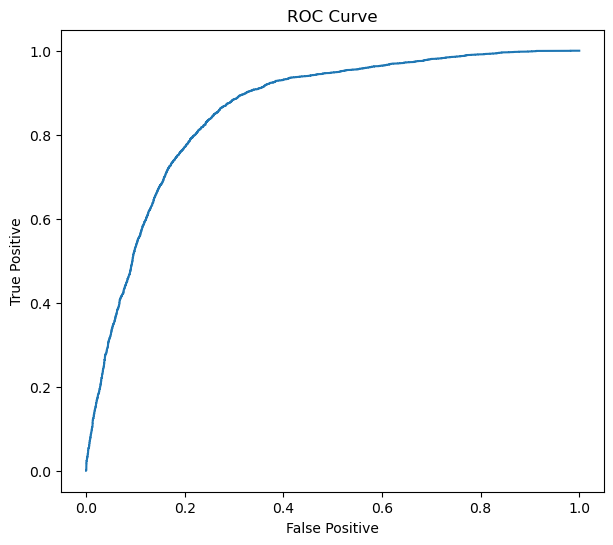

AUC Score: 0.8566361467185222


In [ ]:

fpr, tpr, thresholds = roc_curve(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_pred)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr)
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC Curve")
plt.show()
print(f"AUC Score: {auc_score:}")

---
## Part III: Energy Regression Network

This section builds a second neural network to predict waveform energies through regression, rather than classification.

* The true energy of each waveform typically falls between **0 and 4000**.
* The regression network must accept an input waveform and output a **single floating-point number** (without a strictly bounded range).
* The model's objective is to accurately approximate the true energy value of the given waveform.

We will follow the same three-step procedure used previously: **1. Network Design**, **2.Training**, and **3.Validation**. The overall workflow will look very similar to the Label Network.

### 1. Network Design
The design phase for our regression model consists of two main steps:
1. **Define the Architecture:** Create the `EnergyNetwork` class as a PyTorch `nn.Module`. This defines the network's layers and forward pass.
2. **Validate the Structure:** A single event from `train_set` is passed through the untrained network to validate the architecture.
Let's begin with defining the architecture:

In [ ]:
class EnergyNetwork(nn.Module):
    def __init__(self):
        super(EnergyNetwork, self).__init__()



        self.fc1 = nn.Linear(3800, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 64)
        self.fc4 = nn.Linear(64, 1)
        self.dropout = nn.Dropout(0.0)



    def forward(self, x):


        x = F.relu(self.fc1(x))
      #  x = self.dropout(x)

        x = F.relu(self.fc2(x))
      #  x = self.dropout(x)

        x = F.relu(self.fc3(x))
        output = self.fc4(x)



        return output.squeeze()

A single event was passed through the network to verify the tensor shapes and confirm the architecture works correctly.

* The network should process the event without errors and outputs a tensor of shape `(8, 1)`.

In [ ]:

one_event, one_label, one_energy = next(iter(train_set))
one_event = torch.FloatTensor(one_event).unsqueeze(0).expand(8,-1) # Insert batch dimension, repeat along that dimension 8 times
test_network = EnergyNetwork()
print(test_network(one_event,))

### 2.Training
With the regression network architecture complete, it is time to train the model. MSELoss is used as the loss function, since this is a continuous regression task.

- Unlike the classification task, the loss values for energy regression can become quite large, since the target energies range up to 4000. Removing `nn.BatchNorm1d` layers actually improved the performance for this specific task.

In [ ]:
# Creating training/validation data and networks
NETWORK = EnergyNetwork
TRAIN_SET =  NeutrinoDataset(train_waveform, train_energy, train_label)
TEST_SET =  NeutrinoDataset(test_waveform, test_energy, test_label)

NUM_EPOCHS =30
LEARNING_RATE =2e-4 # 1e-3 is a good learning rate for general purpose
BATCH_SIZE=32
OPTIMIZER = torch.optim.Adam
LOSS_FUNCTION = torch.nn.MSELoss

Dataset Waveform Size:(10000, 3800)
Dataset Energy Label Size:(10000,)
Dataset Classification Label Size:(10000,)
Dataset Waveform Size:(10000, 3800)
Dataset Energy Label Size:(10000,)
Dataset Classification Label Size:(10000,)


In [ ]:
regressor, criterion, optimizer = set_up_classifier(NETWORK,OPTIMIZER, LOSS_FUNCTION)
train_loader, test_loader = get_dataloader(TRAIN_SET, BATCH_SIZE), get_dataloader(TEST_SET, BATCH_SIZE)

for epoch in range(NUM_EPOCHS):
    for i, (waveform, labels, energies) in tqdm(enumerate(train_loader)):
        regressor.train()  # sets the network to train mode

        waveform = waveform.to(DEVICE).float()
        labels = energies.to(DEVICE).float()

        # Forward pass through the regression network
        outputs  = regressor(waveform)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Back-propagate loss to update gradient
        loss.backward()

        # Perform gradient descent to update parameters
        optimizer.step()

        # reset gradient to 0 on all parameters
        optimizer.zero_grad()

    print('\rEpoch [{0}/{1}], Iter [{2}/{3}] Loss: {4:.4f}'.format(
        epoch+1, NUM_EPOCHS, i+1, len(train_loader),
        loss.item(), end=""),end="")


# of params in model:  2093953


312it [00:01, 266.75it/s]


Epoch [1/30], Iter [312/312] Loss: 537.5645

312it [00:01, 217.83it/s]


Epoch [2/30], Iter [312/312] Loss: 400.7912

...

Epoch [28/30], Iter [312/312] Loss: 11685.8887

312it [00:01, 283.83it/s]


Epoch [29/30], Iter [312/312] Loss: 343.5862

312it [00:01, 280.56it/s]

Epoch [30/30], Iter [312/312] Loss: 58.7744

### 3. Validation
The trained model is evaluated on the unseen test dataset. For every test event, two values are collected:
* `y_true`: The ground-truth energy value (typically between 0 and 4000).
* `y_pred`: The model's predicted energy value.

In [ ]:
y_true = []
y_pred = []

for waveform, labels, energies in tqdm(test_loader):

    regressor.eval() # This line set the neural network to evaluation mode, some layers perform differently in train and test mode.

    #While validating the network, we do not want it to produce any gradient. This will also save us time/memory
    with torch.no_grad():

        # Convey waveforms to device, then feed it to the neural network for network output
        waveform = waveform.to(DEVICE).float()
        outputs  = regressor(waveform)

        # Collect predicted vs. true energy for each test event
        outputs = outputs.cpu().data.numpy().flatten()
        labels = energies.cpu().data.numpy().flatten()
        y_true += list(labels)
        y_pred += list(outputs)

100%|██████████| 312/312 [00:00<00:00, 719.44it/s]


For the energy regression task, we are more interested in accurately reconstructing the overall energy distribution rather than achieving perfect event-level precision. Therefore, we will evaluate the model's performance by comparing the histograms of the true and predicted energies.

Energy predictions were evaluated using the following steps:

1. **Create Histograms:** Convert both the `y_true` and `y_pred` arrays into histograms.
   * **Crucial constraint:** The histogram range must be set between **100 and 4000**, with a bin width of **5**.
2. **Extract Counts:** Record the resulting bin counts. Save the `y_true` histogram counts as `true_count` and the `y_pred` histogram counts as `pred_count`.
3. **Calculate Similarity:** Compute the **cosine similarity** between the `true_count` and `pred_count` arrays.



The formula for cosine similarity is defined as:

$$\text{similarity} = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}$$

Where:
* $\mathbf{A} \cdot \mathbf{B}$ is the dot product between vectors $\mathbf{A}$ and $\mathbf{B}$.
* $\|\mathbf{A}\|$ is the $L_2$ norm (Euclidean norm) of vector $\mathbf{A}$.
* This can be computed using `np.linalg.norm`.

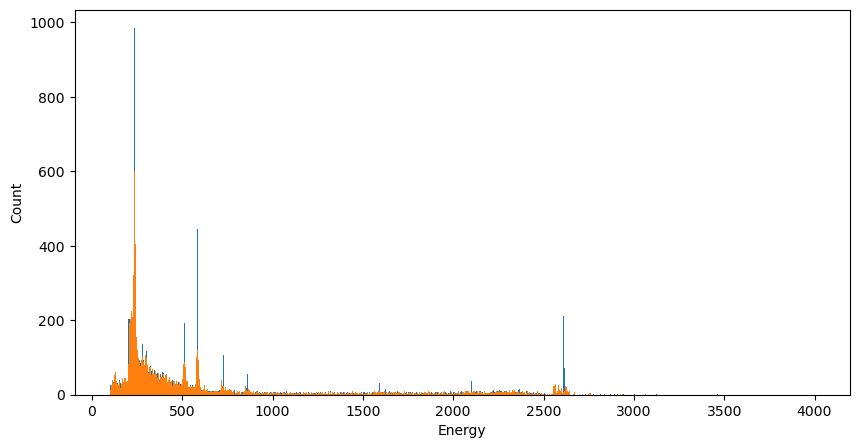

Cosine Similarity: 0.865288731974166


In [ ]:


bins = np.arange(100, 4005, 5)

true_count, i = np.histogram(y_true, bins = bins)
pred_count, i = np.histogram(y_pred, bins = bins)

true_count = true_count.astype(np.float64)
pred_count = pred_count.astype(np.float64)

cosine_similarity = np.dot(true_count, pred_count) / (np.linalg.norm(true_count) * np.linalg.norm(pred_count))

plt.figure(figsize=(10, 5))
plt.hist(y_true, bins=bins, label = "True energy")
plt.hist(y_pred, bins=bins, label = "Predicted energy")

plt.xlabel("Energy")
plt.ylabel("Count")
plt.show()

print(f"Cosine Similarity: {cosine_similarity}")